# Import

In [140]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer
import cvxpy as cp


In [141]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

# Ensure the timestamp is datetime
data["time_stamp"] = pd.to_datetime(data["time_stamp"])

# Sort by ISIN and timestamp to get the correct last entry
data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


# Data Pipeline

In [249]:
# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = (
    data
    .sort_values(["isin", "time_stamp"])
    .reset_index(drop=True)
)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0

data["dy"] = (
    data
    .groupby("isin")["y_dec"]
    .diff()
)
data["dy_bp"] = data["dy"] * 1e4


# ===============================
# VERSION 1 : PnL PRIX
# ===============================

# --- PnL Yield Move (prix)
data["pnl_yield"] = -data["dv01"] * data["dy_bp"]

# --- Carry (coupon estimé via yield) ici c'est bizarre à voir
data["pnl_carry"] = (
    data["price"]/100 * data["y_dec"] / 252 
)

# --- PnL Total
data["pnl_total_unit"] = data["pnl_yield"] + data["pnl_carry"]



# ===============================
# VERSION 2 : RETURN NORMALISÉ DV01
# ===============================

# --- Carry en bp équivalent
data["carry_bp_equiv"] = (
    data["price"]/100 * data["y_dec"] / 252
) / data["dv01"]

# --- Return total
data["ret_total_per_dv01"] = (
    -data["dy_bp"] + data["carry_bp_equiv"]
)
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,y_dec,dy,dy_bp,pnl_yield,pnl_carry,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,0.005400,NaN,NaN,NaN,0.000022,NaN,0.023346,NaN
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,0.004965,-0.000435,-4.35,0.004183,0.000021,0.004203,0.021456,4.371456
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,0.005165,0.000200,2.00,-0.001917,0.000021,-0.001896,0.022345,-1.977655
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,0.004450,-0.000715,-7.15,0.006904,0.000019,0.006923,0.019240,7.169240
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,0.004835,0.000385,3.85,-0.003702,0.000020,-0.003681,0.020921,-3.829079


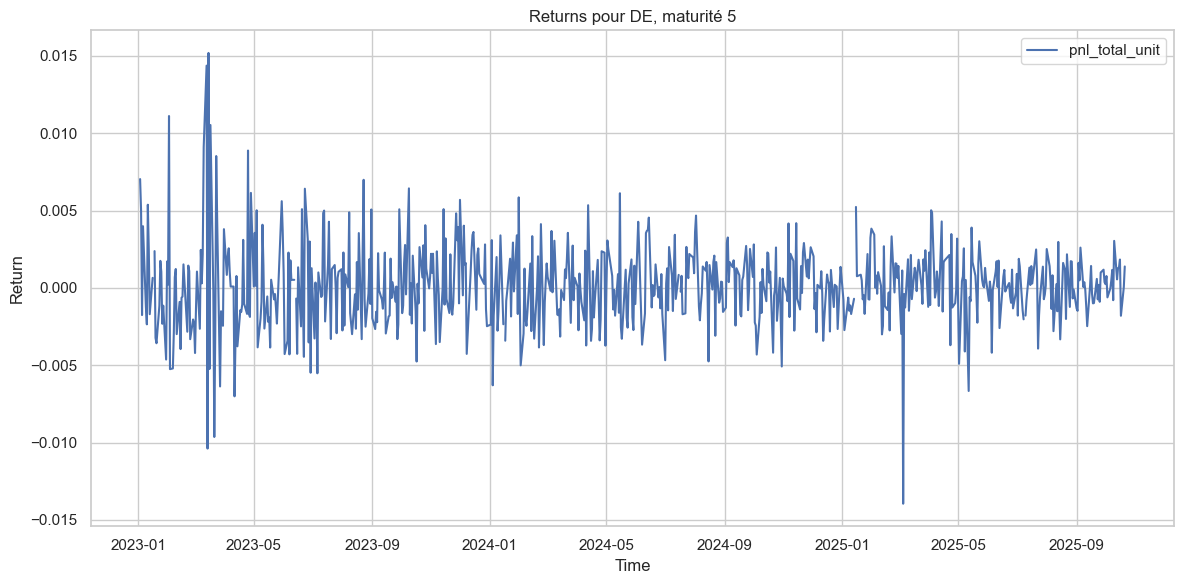

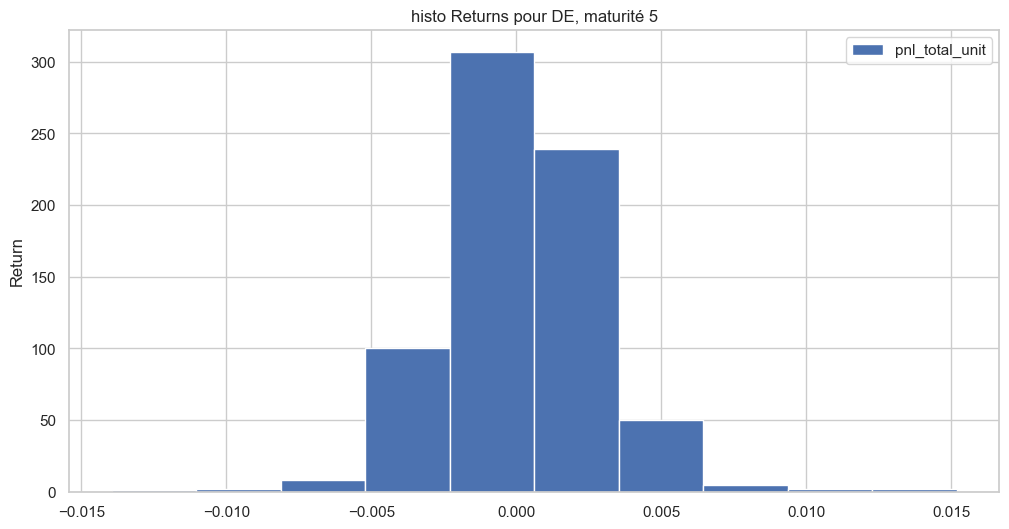

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "ret_total_per_dv01"   # Colonne de return DV01
return_col2 = "pnl_total_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="-")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col2], label=return_col2)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [251]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val1 = "ret_total_per_dv01"
val2 = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val1, val2]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])

data_completed.head()




,time_stamp,ret_total_per_dv01,pnl_total_unit,product
0,2015-01-01,NaN,NaN,DE_10
1,2015-01-02,4.371456,0.004203,DE_10
2,2015-01-05,-1.977655,-0.001896,DE_10
3,2015-01-06,7.169240,0.006923,DE_10
4,2015-01-07,-3.829079,-0.003681,DE_10


## Chargement des bid-offer par bond

In [252]:
bo = pd.read_csv("data/bid_offer_CS.csv")  # adapte le nom si besoin
# Harmonise les types
bo["mat_cat"] = bo["mat_cat"].astype(str)

# On définit le product bond simple : "FR_5", "DE_10", etc.
bo["product"] = bo["country_iso"].astype(str) + "_" + bo["mat_cat"].astype(str)

# On agrège par product (médiane par ex. s'il y a plusieurs ISIN dans le bucket)
bond_bidoffer_yield = (
    bo.groupby("product")["q25_spread_yield"]
    .median()
    .rename("bidoffer_yield_bond")
)

bond_bidoffer_yield.head()

product
AT_10    0.006
AT_15    0.011
AT_2     0.023
AT_20    0.008
AT_3     0.017
Name: bidoffer_yield_bond, dtype: float64

# Ajout spread et curve 

In [253]:
def add_spread_curve(
    data,
    value_col="pnl_total_unit",
    bond_bidoffer_yield=None
):
    """
    Ajoute au format long (time_stamp, product, value_col) :
      - Obligations "outright" : FR_2, DE_10, ...
      - Spreads entre pays à même maturité      : FR_DE_2        (type = spread_country)
      - Curve Spreads intra-pays                : FR_2_5         (type = spread_curve)
      - Butterflies intra-pays                  : FR_fly_2_5_10  (type = butterfly_curve)
      - Box / Différences de pente entre pays   : FR_DE_slope_2_10 (type = slope_diff_country)

    Paramètres
    ----------
    data : DataFrame
        Colonnes attendues : time_stamp, product, value_col
    value_col : str
        Nom de la colonne de return à utiliser
        (ex: "pnl_total_unit" ou "ret_total_per_dv01")
    bond_bidoffer_yield : Series optionnelle
        index = product (ex: "FR_2"), valeurs = bid/offer en yield pour les bonds simples.

    Retour
    ------
    DataFrame long enrichi avec une colonne 'type'
    et 'bid_offer_yield' si disponible.
    """

    df = data.copy()

    # --- Produits originaux ---
    product_type = {p: "bond" for p in df["product"].unique()}

    # --- Extraction pays / maturités ---
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    # --- Pivot large ---
    wide = (
        df
        .pivot(index="time_stamp", columns="product", values=value_col)
        .sort_index()
    )

    # --- Bid / offer par produit ---
    bidoffer_product = {}
    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = bond_bidoffer_yield.loc[p]

    # ============================
    # 1) SPREADS ENTRE PAYS
    # ============================
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2):
                            half_sum = 0.5 * (bo1 + bo2)
                            bidoffer_product[spread_name] = (
                                half_sum * bid_offer_multiplier["spread"]
                            )

    # ============================
    # 2) SPREADS DE COURBE
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"

                        if bond_bidoffer_yield is not None:
                            bo1 = bidoffer_product.get(p1, np.nan)
                            bo2 = bidoffer_product.get(p2, np.nan)
                            if np.isfinite(bo1) and np.isfinite(bo2):
                                half_sum = 0.5 * (bo1 + bo2)
                                bidoffer_product[spread_name] = (
                                    half_sum * bid_offer_multiplier["curve"]
                                )

    # ============================
    # 3) BUTTERFLIES
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        bo3 = bidoffer_product.get(p3, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2) and np.isfinite(bo3):
                            half_sum = 0.5 * (bo1 + bo2 + bo3)
                            bidoffer_product[fly_name] = (
                                half_sum * bid_offer_multiplier["fly"]
                            )

    # ============================
    # 4) BOX / SLOPE DIFF
    # ============================
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            wide[slope_name] = (
                                (wide[p1_high] - wide[p1_low]) -
                                (wide[p2_high] - wide[p2_low])
                            )
                            product_type[slope_name] = "slope_diff_country"

                            if bond_bidoffer_yield is not None:
                                bo1_low  = bidoffer_product.get(p1_low,  np.nan)
                                bo1_high = bidoffer_product.get(p1_high, np.nan)
                                bo2_low  = bidoffer_product.get(p2_low,  np.nan)
                                bo2_high = bidoffer_product.get(p2_high, np.nan)

                                if all(np.isfinite(x) for x in [bo1_low, bo1_high, bo2_low, bo2_high]):
                                    half_sum = 0.5 * (bo1_low + bo1_high + bo2_low + bo2_high)
                                    bidoffer_product[slope_name] = (
                                        half_sum * bid_offer_multiplier["box"]
                                    )

    # ============================
    # Retour format long
    # ============================
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name=value_col
    )

    long["type"] = long["product"].map(product_type).fillna("unknown")

    if bond_bidoffer_yield is not None:
        bo_series = pd.Series(bidoffer_product)
        long["bid_offer_yield"] = long["product"].map(bo_series)

    return long


In [254]:
bid_offer_multiplier = {
    "fly": 0.25,
    "box": 0.375,
    "spread": 0.5,
    "curve": 0.4,
}
long = add_spread_curve(data_completed,value_col="pnl_total_unit",  bond_bidoffer_yield=bond_bidoffer_yield)
long2 = add_spread_curve(data_completed,value_col="ret_total_per_dv01",  bond_bidoffer_yield=bond_bidoffer_yield)
long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]
long.head(10)

long[long["type"].isin(["bond", "spread_country", "spread_curve", "butterfly_curve", "slope_diff_country"])] \
    .groupby("type")["bid_offer_yield"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
bond,34920.0,0.008533,0.005476,0.002000,0.004000,0.006000,0.014000,0.020000
butterfly_curve,20952.0,0.002792,0.001402,0.001125,0.001875,0.002125,0.003750,0.005375
slope_diff_country,69840.0,0.006400,0.002084,0.002625,0.004875,0.006562,0.008062,0.010313
spread_country,34920.0,0.004267,0.001948,0.001250,0.002250,0.004250,0.006250,0.007250
spread_curve,69840.0,0.003413,0.001760,0.001000,0.001800,0.003000,0.004600,0.007400


In [255]:
long.head()

,time_stamp,product,pnl_total_unit,type,bid_offer_yield,ret_total_per_dv01
0,2015-01-01,DE_10,NaN,bond,0.003,NaN
1,2015-01-02,DE_10,0.004203,bond,0.003,4.371456
2,2015-01-05,DE_10,-0.001896,bond,0.003,-1.977655
3,2015-01-06,DE_10,0.006923,bond,0.003,7.169240
4,2015-01-07,DE_10,-0.003681,bond,0.003,-3.829079


# Class Portfolio à date t 

In [303]:
class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        delta=0.1,
        tc_gamma=0.1
    ):
        """
        Classe Portfolio : initialise un portefeuille pour optimisation Markowitz
        basé sur des returns DV01-normalisés.

        Paramètres
        ----------
        data : pd.DataFrame
            Historique des produits avec au moins les colonnes :
            'time_stamp', 'product', 'pnl_total_unit', éventuellement 'ret_total_per_dv01'.
        date : datetime-like
            Date de rebalancement / estimation. Seules les données avant cette date sont utilisées.
        benchmark : str, default "ew"
            Nom du benchmark pour comparaison (ex: equal-weighted).
        long_only : bool, default True
            Si True, les poids sont projetés sur le simplexe (pas de short).
        lamb : float, default 1.0
            Paramètre d’aversion au risque λ pour Markowitz : maximise μ'w - λ w'Σw.
        rebalancement : str, default 'ME'
            Fréquence de rebalancement :
            'D' = quotidien, 'W' = hebdomadaire, 'M' = mensuel, 'ME' = fin de mois.
        span : int, default 6
            Demi-vie pour calcul EWMA des retours moyens.
        initial_weights : array-like or None, default None
            Poids initiaux du portefeuille, pour démarrer l’optimisation.
        delta : float, default 0.1
            Paramètre de régularisation / limite de variation de poids.
        tc_gamma : float, default 0.1
            Coefficient de coût de transaction.

        Attributs internes
        ------------------
        self.data : pd.DataFrame
        self.date : pd.Timestamp
        self.benchmark : str
        self.long_only : bool
        self.lamb : float
        self.rebalancement : str
        self.sigma_level : float
        self.span : int
        self.initial_weights : array-like or None
        self.delta : float
        self.tc_gamma : float

        self.returns : pd.DataFrame
            Returns filtrés jusqu'à self.date.
        self.mean_returns : pd.DataFrame or pd.Series
            Moyenne des retours (EWMA).
        self.cov_matrix : pd.DataFrame
            Matrice de covariance des returns.
        self.weights : pd.Series or np.array
            Poids optimisés pour la période courante.
        self.benchmark_weights : pd.Series or np.array
            Poids du benchmark pour comparaison.
        """

        # --- données et date ---
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark

        # --- paramètres optimisation ---
        self.long_only = long_only
        self.lamb = float(lamb)
        self.rebalancement = rebalancement
        self.span = span
        self.delta = delta
        self.tc_gamma = float(tc_gamma)
        self.initial_weights = initial_weights

        # --- attributs internes ---
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.benchmark_weights = None

    def get_returns_until(self):
        """Filter returns up to self.date and resample according to rebalancement."""
        R = self.data[self.data["time_stamp"] < self.date].copy()

        # --- resampling selon la fréquence de rebalancement ---
        if hasattr(self, "rebalancement") and self.rebalancement in ["D", "W", "ME"]:
            df_list = []
            for prod, df_prod in R.groupby("product"):
                df_prod = df_prod.set_index("time_stamp").sort_index()
                if self.rebalancement != "D":
                    df_resampled = df_prod["ret_total_per_dv01"].resample(self.rebalancement).sum()
                else:
                    df_resampled = df_prod["ret_total_per_dv01"]
                df_resampled = df_resampled.reset_index()
                df_resampled["product"] = prod
                df_list.append(df_resampled)
            R = pd.concat(df_list, axis=0)
        else:
            # default = daily
            R = R.copy()

        self.returns = R.sort_values(["product", "time_stamp"])


    def estimate_returns(self):
        """EWMA (exponential weighted mean) of returns per product."""
        span = self.span  # span controlling the half-life

        # on prend seulement date, produit et return
        df = self.returns[["time_stamp", "product", "ret_total_per_dv01"]].copy()
        df = df.sort_values(["product", "time_stamp"])

        # --- EWMA par produit ---
        ewma = (
            df.groupby("product")["ret_total_per_dv01"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_ret_dv01")
        )

        self.mean_returns = ewma

    def estimate_cov_matrix_Ledoit(self):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage.
        """
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="ret_total_per_dv01"
        ).sort_index()

        X = panel.fillna(0).values
        lw = LedoitWolf().fit(X)     
        cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(
            cov_matrix,
            columns=panel.columns,
            index=panel.columns
        )
        
    def markowitz2_qp(self):
        """
        Version QP de Markowitz avec coûts de transaction linéaires en turnover.
        """

        # 1) μ et Σ
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        Sigma = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        gamma_tc = self.tc_gamma
        long_only = self.long_only

        # --- PATCH NUMERIQUE SUR Σ ---
        Sigma = 0.5 * (Sigma + Sigma.T)         # symétrisation
        Sigma = Sigma + 1e-8 * np.eye(n)        # régularisation diagonale

        # 2) w_prev aligné
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # 3) c_vec depuis bid_offer_yield
        if "bid_offer_yield" in self.data.columns:
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # 4) Variables
        w = cp.Variable(n)
        t = cp.Variable(n)

        # 5) Bornes dynamiques
        if long_only:
            w_min = np.zeros(n)
            w_max = w_prev + self.delta
        else:
            w_min = w_prev - self.delta
            w_max = w_prev + self.delta

        # 6) Contraintes
        constraints = [
            cp.sum(w) == 1,
            w >= w_min,
            w <= w_max,
            t >= w - w_prev,
            t >= -(w - w_prev),
            t >= 0
        ]

        # 7) Objectif
        quad_term = lambda_risk * cp.quad_form(w, cp.psd_wrap(Sigma))
        mean_term = - mean_returns @ w
        if gamma_tc > 0 and np.any(c_vec != 0):
            tc_term = gamma_tc * (c_vec @ t)
        else:
            tc_term = 0

        objective = cp.Minimize(quad_term + mean_term + tc_term)

        # 8) Résolution
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP, verbose=False)
        except Exception:
            prob.solve(solver=cp.SCS, verbose=False)

        if w.value is None:
            raise ValueError("Optimisation QP échouée : statut = " + prob.status)

        w_opt = np.array(w.value).flatten()

        # 9) Nettoyage
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        if w_opt.sum() != 0:
            w_opt = w_opt / w_opt.sum()

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights



    def markowitz2(self):

        # ---- 1) Vecteur de rendements attendus ----
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        long_only = self.long_only
        gamma_tc = getattr(self, "tc_gamma", 0.0)
        eps_tc = 1e-8  # pour lisser |x| ≈ sqrt(x^2 + eps)

        # ---- 2) Poids précédents (w_prev), correctement alignés ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                # on prend la première colonne si DataFrame
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                # numpy array ou liste
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # ---- 3) Coefficients de coût c_i à partir des bid_offer_yield ----
        if ("bid_offer_yield" in self.data.columns):
            # médiane sur l’historique pour chaque product
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # ---- 4) Fonction objectif avec coûts de transaction ----
        def objective(w):
            # risque
            risk_term = lambda_risk * (w @ cov_matrix @ w)
            # rendement
            mean_term = - (w @ mean_returns)
            # coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff * diff + eps_tc))
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        # ---- 5) Gradient de l’objectif ----
        def grad_objective(w):
            # dérivée risk
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w)
            # dérivée rendement
            grad_mean = -mean_returns
            # dérivée coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                denom = np.sqrt(diff * diff + eps_tc)
                grad_tc = gamma_tc * c_vec * (diff / denom)
            else:
                grad_tc = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        # ---- 6) Contraintes et bornes ----
        constraints = [
            {'type': 'eq',
            'fun': lambda w: np.sum(w) - 1.0,
            'jac': lambda w: np.ones_like(w)}
        ]

        # Bornes dynamiques (comme ta V2)
        bounds = []
        if long_only:
            for wp in w_prev:
                # poids min 0, max wp + delta
                bounds.append((max(0,wp - self.delta), wp + self.delta))
        else:
            for wp in w_prev:
                bounds.append((wp - self.delta, wp + self.delta))


        # ---- 7) Initialisation ----
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds])
        if w0.sum() == 0:
            w0 = np.ones(n) / n
        else:
            w0 = w0 / w0.sum()



        # ---- 9) Nettoyage / normalisation ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        if w_opt.sum() != 0:
            w_opt = w_opt / w_opt.sum()

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights

    def markowitz_robust(self):
        """
        Optimisation Markowitz robuste avec contrôle du turnover.
        - mean_returns et cov_matrix doivent être déjà définis.
        - long_only : si True, les poids >= 0
        - delta : limite de variation des poids par rapport à w_prev
        - gamma_tc : poids du coût de transaction
        """
        # ---- 1) Rendements attendus et covariance ----
        mean_returns = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean_returns = mean_returns.reindex(self.cov_matrix.index).fillna(0.0).values
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        
        # ---- 2) Poids précédents ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        else:
            w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
            w_prev = w_prev_series.values

        # ---- 3) Coût de transaction ----
        if "bid_offer_yield" in self.data.columns:
            c_vec = self.data.groupby("product")["bid_offer_yield"].median()
            c_vec = c_vec.reindex(self.cov_matrix.index).fillna(0.0).values
        else:
            c_vec = np.zeros(n)
        
        lambda_risk = self.lamb
        gamma_tc = getattr(self, "tc_gamma", 0.0)
        eps_tc = 1e-8

        # ---- 4) Fonction objectif ----
        def objective(w):
            risk_term = lambda_risk * (w @ cov_matrix @ w)
            mean_term = - (w @ mean_returns)
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff**2 + eps_tc))
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        # ---- 5) Gradient ----
        def grad_objective(w):
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w)
            grad_mean = -mean_returns
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                grad_tc = gamma_tc * c_vec * (diff / np.sqrt(diff**2 + eps_tc))
            else:
                grad_tc = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        # ---- 6) Contraintes ----
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0,
                        'jac': lambda w: np.ones_like(w)}]

        # ---- 7) Bornes ----
        bounds = []
        if self.long_only:
            for wp in w_prev:
                lower = max(0.0, wp - self.delta)
                upper = min(1.0, wp + self.delta)
                bounds.append((lower, upper))
        else:
            for wp in w_prev:
                bounds.append((wp - self.delta, wp + self.delta))

        # ---- 8) Initialisation ----
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds])
        if w0.sum() == 0:
            w0 = np.ones(n) / n
        else:
            w0 = w0 / w0.sum()

        # ---- 9) Optimisation ----
        res = minimize(
            objective, w0, jac=grad_objective,
            constraints=constraints, bounds=bounds,
            method='SLSQP',
            options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000}
        )
    
        if not res.success:
            # Au lieu de lever une exception, on reprend les poids précédents
            print(f"Optimisation échouée à {self.date}, on reprend les poids précédents")
            w_opt = w_prev.copy()
        else:
            w_opt = res.x


        w_opt = res.x

        # ---- 10) Nettoyage ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        if w_opt.sum() != 0:
            w_opt = w_opt / w_opt.sum()

        # ---- 11) Retour ----
        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights


    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self, use_qp=False):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_Ledoit()

        """        
        if use_qp:
            self.markowitz2_qp()
        else:
            self.markowitz2()   # ta version SLSQP existante
        """
        self.markowitz_robust()
        self.benchmark_w()
        return self.weights



In [304]:
date = "2021-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True,lamb=0.1)
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

                 2021-06-01
product                    
DE_10              0.000000
DE_10_15           0.000000
DE_10_30           0.000000
DE_15              0.000000
DE_15_30           0.000000
...                     ...
IT_5_15            0.110101
IT_5_30            0.110101
IT_fly_10_15_30    0.000000
IT_fly_2_5_10      0.000000
IT_fly_5_10_15     0.000000

[99 rows x 1 columns]


C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


# Creation du time series portfolio

In [305]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='ME',
                 long_only=False, lamb=0.1, benchmark="ew", 
                capital_init=100_000, span = 6, initial_weights= None, delta = 0.1, tc_gamma=0.0, use_qp=False):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.capital_init = capital_init
        self.span = span
        
        self.tc_gamma = float(tc_gamma)
        self.use_qp = bool(use_qp)

        self.delta = delta
        self.initial_weights = initial_weights
        
        # Univers global d'actifs (tous les products jamais vus dans self.data)
        self.asset_universe = sorted(self.data["product"].unique())
        
        self.countries = sorted({p.split("_")[0] for p in self.asset_universe})

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # *** Séries de bid-offer par produit (en yield), agrégées sur le temps
        if "bid_offer_yield" in self.data.columns:
            # médiane sur l'historique, par product
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .rename("bid_offer_yield")
            )
        else:
            # pas d'info => 0
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f == 'ME':
            return f
        if f.endswith(('D', 'B', 'W')):
            return f
        return 'ME'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_rel_returns = []
        bm_rel_returns= []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        # *** tracking des coûts de transaction
        tc_dates = []
        tc_values = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital
        w = self.initial_weights

        # *** expositions précédentes (pour calculer les deltas)
        prev_exposure_full = pd.Series(0.0, index=self.asset_universe)

        # *** vecteur de bid-offer aligné sur l'univers global
        bo_full = self.bidoffer_by_product.reindex(self.asset_universe).fillna(0.0)

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                span=self.span,
                initial_weights=w,
                delta=self.delta,
                tc_gamma=self.tc_gamma,   # <--- important
            )
            
            w_df = pf.process()

            w = w_df.iloc[:, 0]  # Series: index = produits présents dans Σ à cette date

            # 1) Reindexer les poids sur l'univers global, en mettant 0 où l'actif n'est pas dans Σ
            w_full = w.reindex(self.asset_universe).fillna(0.0)

            # Benchmark
            w_bm = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # 2) Normalisation des expositions
            target_notional = self.capital_init
            denom_pf = np.sum(np.abs(w_full.values))
            if denom_pf > 0:
                exposure_full = w_full * (target_notional / denom_pf)
            else:
                exposure_full = w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            if denom_bm > 0:
                exposure_bm_full = w_bm * (target_notional / denom_bm)
            else:
                exposure_bm_full = w_bm.copy()

            # *** 2bis) Coût de transaction du rebalance (en PnL)
            # delta d'exposition (nouveau - ancien) sur chaque produit
            delta_exposure_full = exposure_full - prev_exposure_full

            # coût total = somme |delta_expo| * bid_offer_yield_effectif
            # (bid_offer_yield est déjà une "demi-spread" efficace par ton design)
            tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_full.values)

            # on met à jour les expositions précédentes
            prev_exposure_full = exposure_full.copy()

            # 3) Slice des PnL unitaires pour la période (t, t_next]
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp",
                columns="product",
                values="pnl_total_unit"
            )

            # On garde uniquement les colonnes de l’univers global (intersection)
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice = R_slice[common_cols].fillna(0.0)

            # 4) Aligner les expositions sur ces colonnes
            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            # 5) PnL par jour (mid-market)
            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm

            # *** Intégration du coût de transaction au PnL du portefeuille
            if len(pf_pnl_day) > 0:
                # on impute le coût le jour du rebalance (premier jour de la période)
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                # cas rare où il n'y aurait pas de date entre t et t_next :
                # on enregistre le coût à la date de rebalance t
                tc_dates.append(t)
                # on ajoute un PnL "artificiel" -tc_total
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                # on ajoute aussi une pseudo-date
                R_slice = pd.DataFrame(
                    index=[t],
                    data=np.zeros((1, len(common_cols))),
                    columns=common_cols
                )

            tc_values.append(tc_total)

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            # 6) Stocker les poids / expositions sur l’univers global
            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )


        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_rel_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_rel_returns, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        # *** série des coûts de transaction
        tc_series = pd.Series(tc_values, index=pd.DatetimeIndex(tc_dates))

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs": tc_series,     # *** nouvelle entrée
        }

        print("Tout a marché !!")

    
    def _decompose_product_legs(self, product):
        """
        Décompose un product en jambes élémentaires (country, maturity, coef).

        Conventions de nommage gérées :
          - Bond simple           : FR_5
          - Spread pays           : FR_DE_5              -> +FR_5, -DE_5
          - Spread courbe         : FR_2_5 ou FR_10_5    -> +FR_2/10, -FR_5
          - Butterfly intra-pays  : FR_fly_2_5_10        -> +FR_2, -2 FR_5, +FR_10
          - Slope diff pays       : FR_DE_slope_2_10     -> (FR_10 - FR_2) - (DE_10 - DE_2)

        Retourne une liste de tuples (country, maturity, coef).
        """
        parts = product.split("_")

        # Bond simple : "FR_5"
        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        # Cas len(parts) == 3 : soit spread pays FR_DE_5, soit spread courbe FR_2_5 / FR_10_5
        if len(parts) == 3:
            p0, p1, p2 = parts

            # On utilise la vraie liste de pays pour décider
            # 1) Spread pays : FR_DE_5
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                c1, c2, mat = p0, p1, p2
                return [(c1, mat,  1.0),
                        (c2, mat, -1.0)]

            # 2) Spread courbe : FR_2_5, FR_10_5, etc.
            if p0 in getattr(self, "countries", []):
                c, m1, m2 = p0, p1, p2
                return [(c, m1,  1.0),
                        (c, m2, -1.0)]

        # Butterfly : FR_fly_2_5_10
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1,  1.0),
                    (c, m2, -2.0),
                    (c, m3,  1.0)]

        # Slope diff pays : FR_DE_slope_2_10
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        # Cas non reconnu : on ignore
        return []

    
    def exposition_by_country(self):
        """
        Calcule l'exposition par pays en tenant compte des combinaisons linéaires
        des produits (bonds, spreads, butterflies, slopes).

        Pour chaque produit j et chaque jour t :
        expo_country[c, t] = somme_j ( expo_j(t) * coef_{j,c,*} )
        où coef_{j,c,*} vient de la décomposition en jambes (country, maturity, coef).
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        # Pré-calcul des jambes pour chaque produit
        legs_by_product = {}
        countries = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                countries.add(c)

        if not countries:
            # Aucun produit reconnu -> on renvoie un DF vide mais bien formé
            return pd.DataFrame(index=df.index)

        # DataFrame resultat : dates x pays
        countries = sorted(countries)
        expo_by_country = pd.DataFrame(0.0, index=df.index, columns=countries)

        # Agrégation : pour chaque produit, répartir son expo sur les pays
        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]  # Series index=date

            for c, m, coef in legs:
                expo_by_country[c] += coef * exp_p

        return expo_by_country
    
    def exposition_by_mat(self):
        """
        Calcule l'exposition par maturité (toutes devises confondues) en tenant
        compte des combinaisons linéaires des produits.

        Pour chaque produit j et chaque jour t :
        expo_mat[m, t] = somme_j ( expo_j(t) * coef_{j,*,m} )
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        legs_by_product = {}
        maturities = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                maturities.add(m)

        if not maturities:
            return pd.DataFrame(index=df.index)

        maturities = sorted(maturities, key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x)
        expo_by_mat = pd.DataFrame(0.0, index=df.index, columns=maturities)

        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]

            for c, m, coef in legs:
                expo_by_mat[m] += coef * exp_p

        return expo_by_mat





In [306]:
long

,time_stamp,product,pnl_total_unit,type,bid_offer_yield,ret_total_per_dv01
0,2015-01-01,DE_10,NaN,bond,0.00300,NaN
1,2015-01-02,DE_10,0.004203,bond,0.00300,4.371456
2,2015-01-05,DE_10,-0.001896,bond,0.00300,-1.977655
3,2015-01-06,DE_10,0.006923,bond,0.00300,7.169240
4,2015-01-07,DE_10,-0.003681,bond,0.00300,-3.829079
...,...,...,...,...,...,...
230467,2025-10-15,FR_IT_slope_15_30,-0.000139,slope_diff_country,0.00825,-0.974260
230468,2025-10-16,FR_IT_slope_15_30,0.000573,slope_diff_country,0.00825,0.195472
230469,2025-10-17,FR_IT_slope_15_30,-0.001561,slope_diff_country,0.00825,-0.344262
230470,2025-10-20,FR_IT_slope_15_30,-0.000693,slope_diff_country,0.00825,0.455382


In [307]:
L = long.groupby("product")["pnl_total_unit"].mean().index
weights_dict = {p: 0.0 for p in L}
#print(L)
weights_dict['DE_10'] = 0.1
weights_dict['FR_10'] = 0.2
weights_dict['IT_5'] = 0.7

df_weights = pd.DataFrame(list(weights_dict.items()), columns=['product', 'weight'])

In [309]:
df_weights

,product,weight
0,DE_10,0.1
1,DE_10_15,0.0
2,DE_10_30,0.0
3,DE_15,0.0
4,DE_15_30,0.0
...,...,...
94,IT_5_15,0.0
95,IT_5_30,0.0
96,IT_fly_10_15_30,0.0
97,IT_fly_2_5_10,0.0


C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
C:\Users\hugoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\

Tout a marché !!


c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pf_m = pf_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:97: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bm_m = bm_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:232: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pf_m = pf_value.resample('M').last()
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:233: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bm_m = bm_value.resample('M').last() if bm_value is not None else N

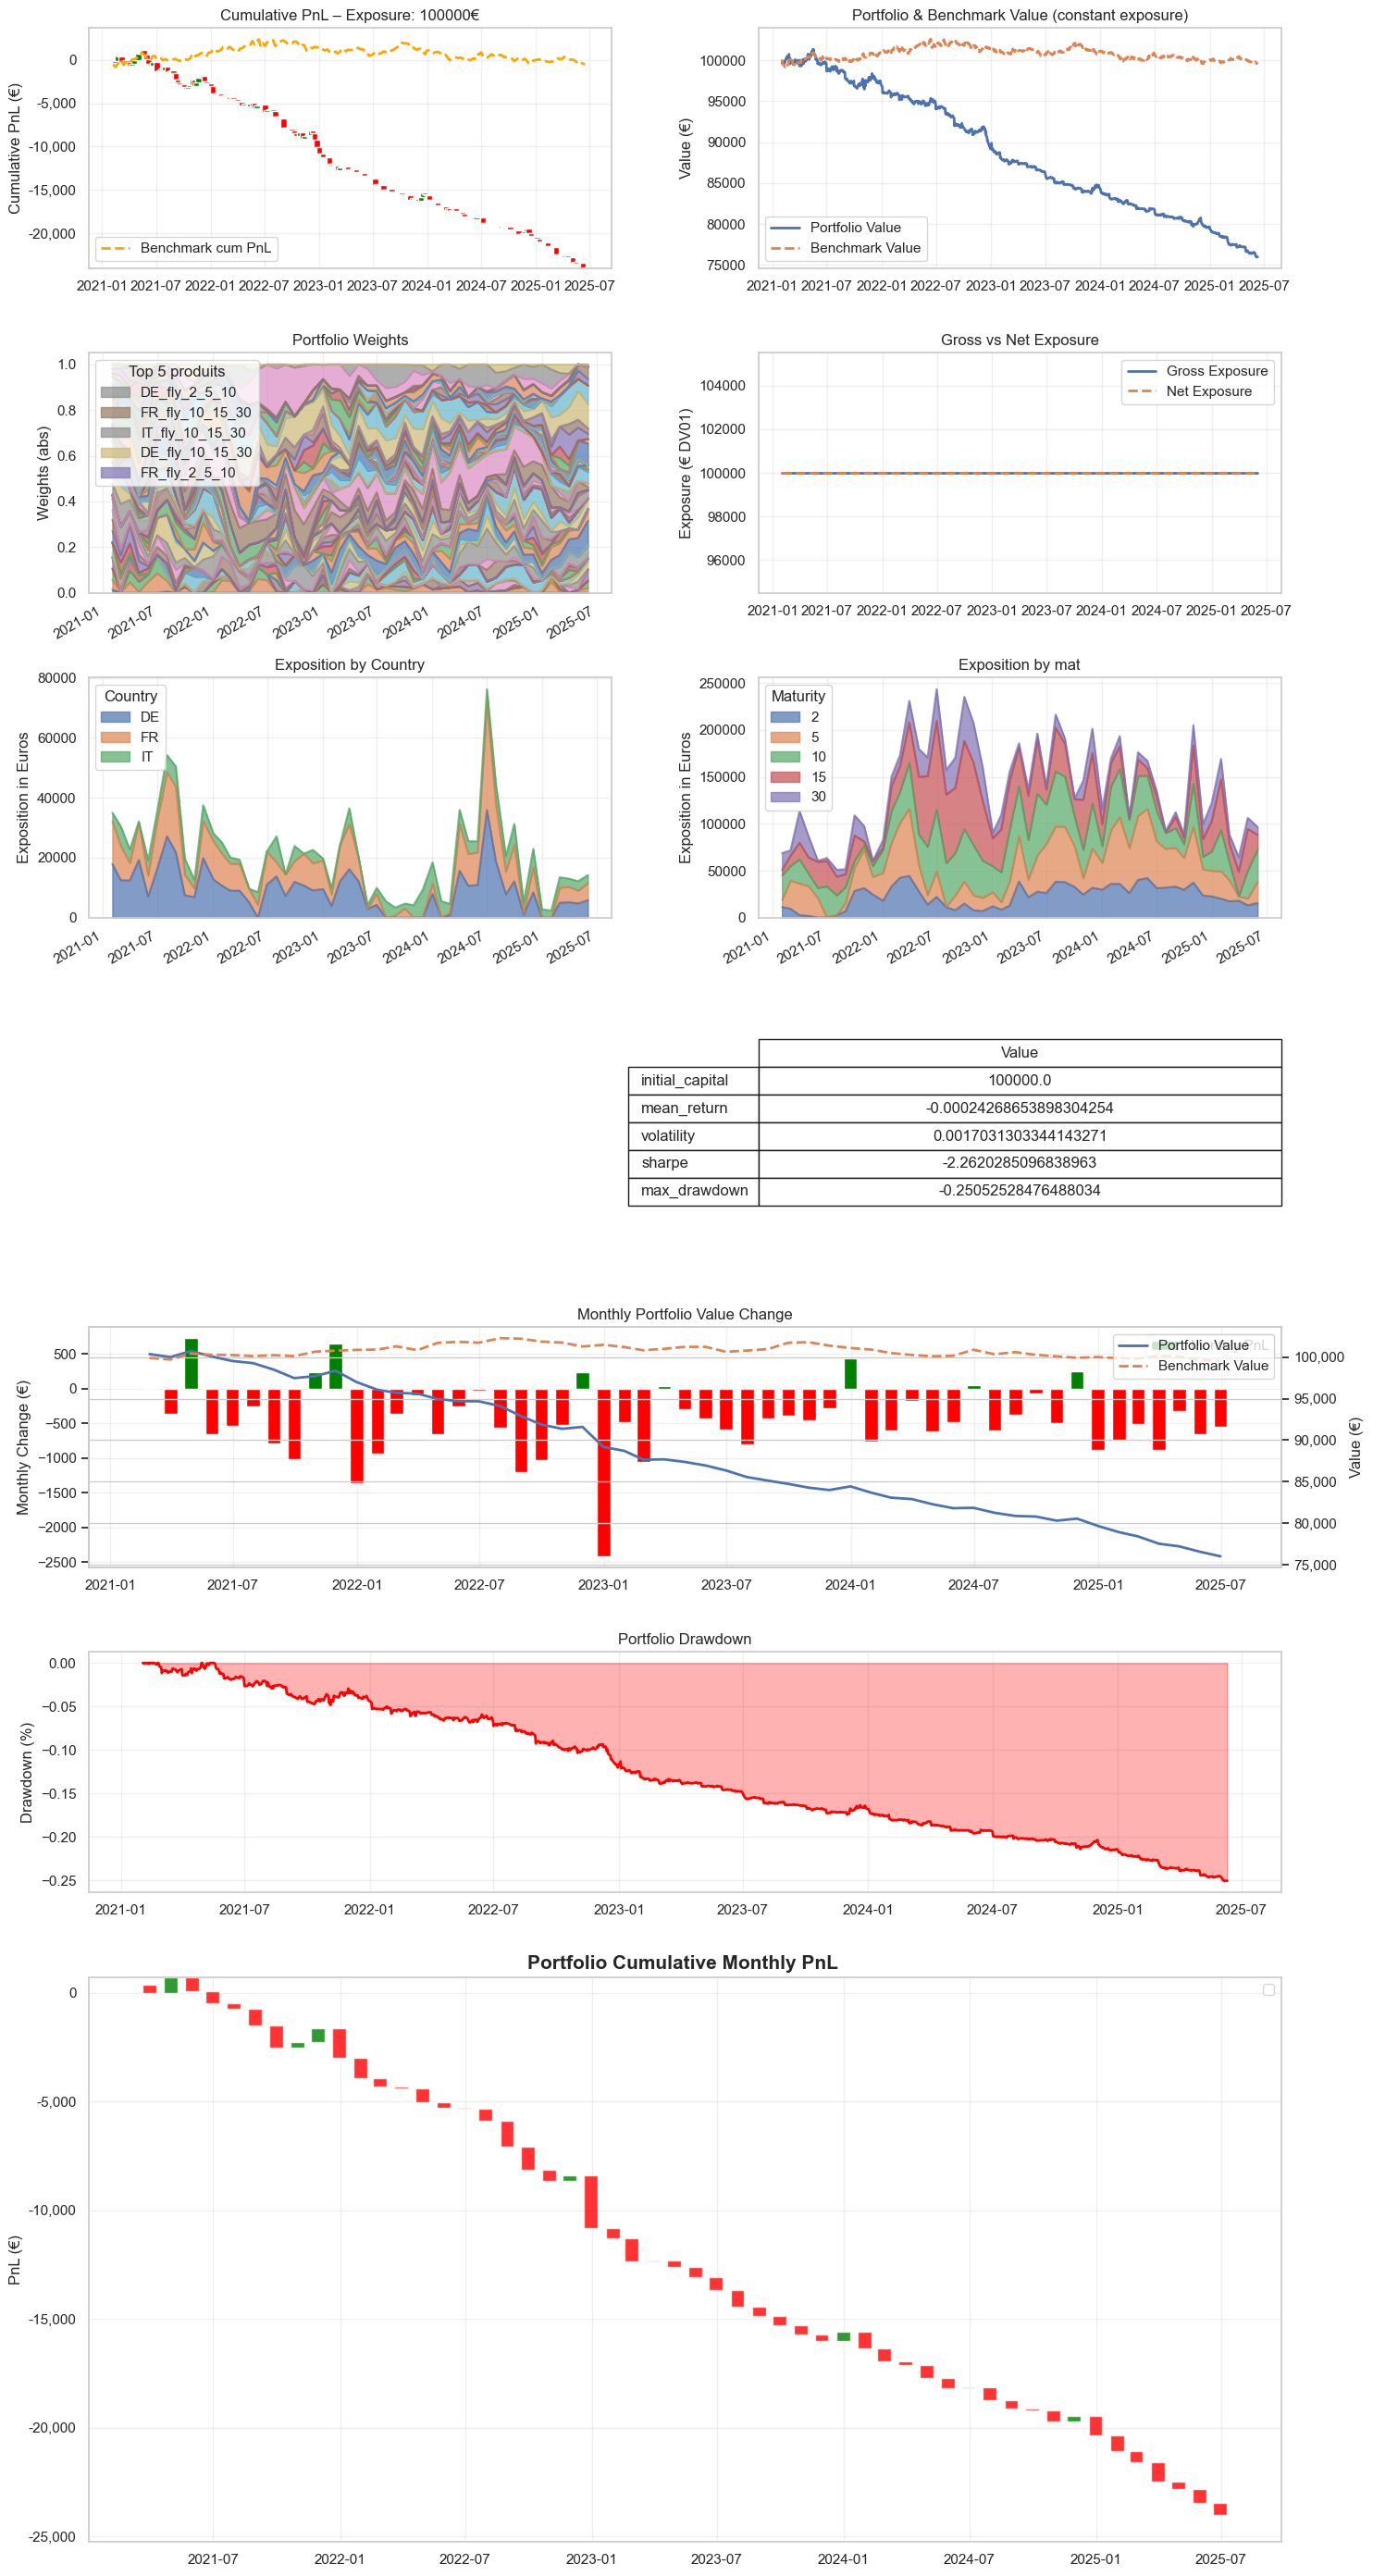

In [308]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="1M",
    long_only=True,
    lamb=1,
    benchmark="ew",
    span=3,
    delta=0.05,
    tc_gamma=0.5,   # intensité des coûts dans l’optimisation
    initial_weights= df_weights["weight"]
)


tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)
viz.plot_dashboard()